# Diabetes Prediction using Multilayer Perceptron (MLP)

**Lab Assignment 01 — Complete End-to-End Implementation**

This notebook follows the assignment workflow: dataset understanding, EDA, data quality checks, preprocessing, feature engineering, train/test split, multiple baseline models, MLP development, evaluation, hyperparameter tuning, final model selection, model saving, and deployment preparation.

**Important:** All performance metrics are calculated from the dataset at runtime; no results are hard-coded.

## 1. Install and Import Required Libraries

In [ ]:
!pip install -q tensorflow scikit-learn pandas numpy matplotlib seaborn joblib

import os
import time
import random
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, average_precision_score
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Libraries imported successfully.")

TensorFlow: 2.20.0
Libraries imported successfully.


## 2. Load the Pima Indians Diabetes Dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/diabetes.csv")


columns = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"
]

# The dataframe `df` is already loaded from the above statement, so there is no need to load it again.
# If the intent was to rename the columns, it should be done as `df.columns = columns`.

print("Dataset loaded successfully.")

Dataset loaded successfully.


## 3. Dataset Understanding

In [ ]:
display(df.head())
display(df.tail())

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nDescriptive statistics:")
display(df.describe())

print("\nDataset information:")
df.info()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


Shape: (768, 9)

Columns:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Data types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Descriptive statistics:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


## 4. Target/Class Distribution

Class counts:
Outcome
0    500
1    268
Name: count, dtype: int64

Class percentages:
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


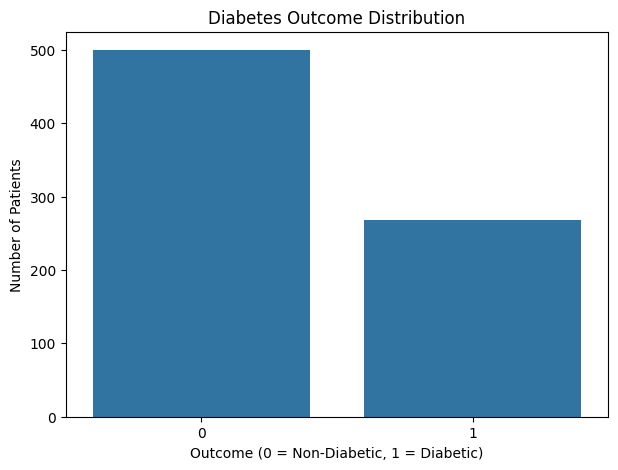

In [ ]:
target_counts = df["Outcome"].value_counts().sort_index()
target_percentages = df["Outcome"].value_counts(normalize=True).sort_index() * 100

print("Class counts:")
print(target_counts)

print("\nClass percentages:")
print(target_percentages)

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Outcome")
plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome (0 = Non-Diabetic, 1 = Diabetic)")
plt.ylabel("Number of Patients")
plt.show()

## 5. Missing Values, Duplicates and Suspicious Values

In [ ]:
print("Missing values:")
display(pd.DataFrame({
    "Missing": df.isna().sum(),
    "Percentage": df.isna().mean() * 100
}))

print("Duplicate rows:", df.duplicated().sum())

clinical_columns = [
    "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"
]

zero_table = pd.DataFrame({
    "Zero Count": (df[clinical_columns] == 0).sum(),
    "Percentage": (df[clinical_columns] == 0).mean() * 100
})

print("\nSuspicious zero values:")
display(zero_table)

df_clean = df.copy()

# For these clinical variables, zero is treated as missing rather than
# as a genuine physiological measurement.
for col in clinical_columns:
    df_clean[col] = df_clean[col].replace(0, np.nan)

if df_clean.duplicated().sum() > 0:
    df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print("Data-quality preprocessing completed.")

Missing values:


,Missing,Percentage
Pregnancies,0,0.0
Glucose,0,0.0
BloodPressure,0,0.0
SkinThickness,0,0.0
Insulin,0,0.0
BMI,0,0.0
DiabetesPedigreeFunction,0,0.0
Age,0,0.0
Outcome,0,0.0


Duplicate rows: 0

Suspicious zero values:


,Zero Count,Percentage
Glucose,5,0.651042
BloodPressure,35,4.557292
SkinThickness,227,29.557292
Insulin,374,48.697917
BMI,11,1.432292


Data-quality preprocessing completed.


## 6. Univariate EDA

,Mean,Median,Std Dev,Minimum,Maximum,Skewness
Pregnancies,3.845052,3.0000,3.369578,0.000,17.00,0.901674
Glucose,121.686763,117.0000,30.535641,44.000,199.00,0.530989
BloodPressure,72.405184,72.0000,12.382158,24.000,122.00,0.134153
SkinThickness,29.153420,29.0000,10.476982,7.000,99.00,0.690619
Insulin,155.548223,125.0000,118.775855,14.000,846.00,2.166464
BMI,32.457464,32.3000,6.924988,18.200,67.10,0.593970
DiabetesPedigreeFunction,0.471876,0.3725,0.331329,0.078,2.42,1.919911
Age,33.240885,29.0000,11.760232,21.000,81.00,1.129597


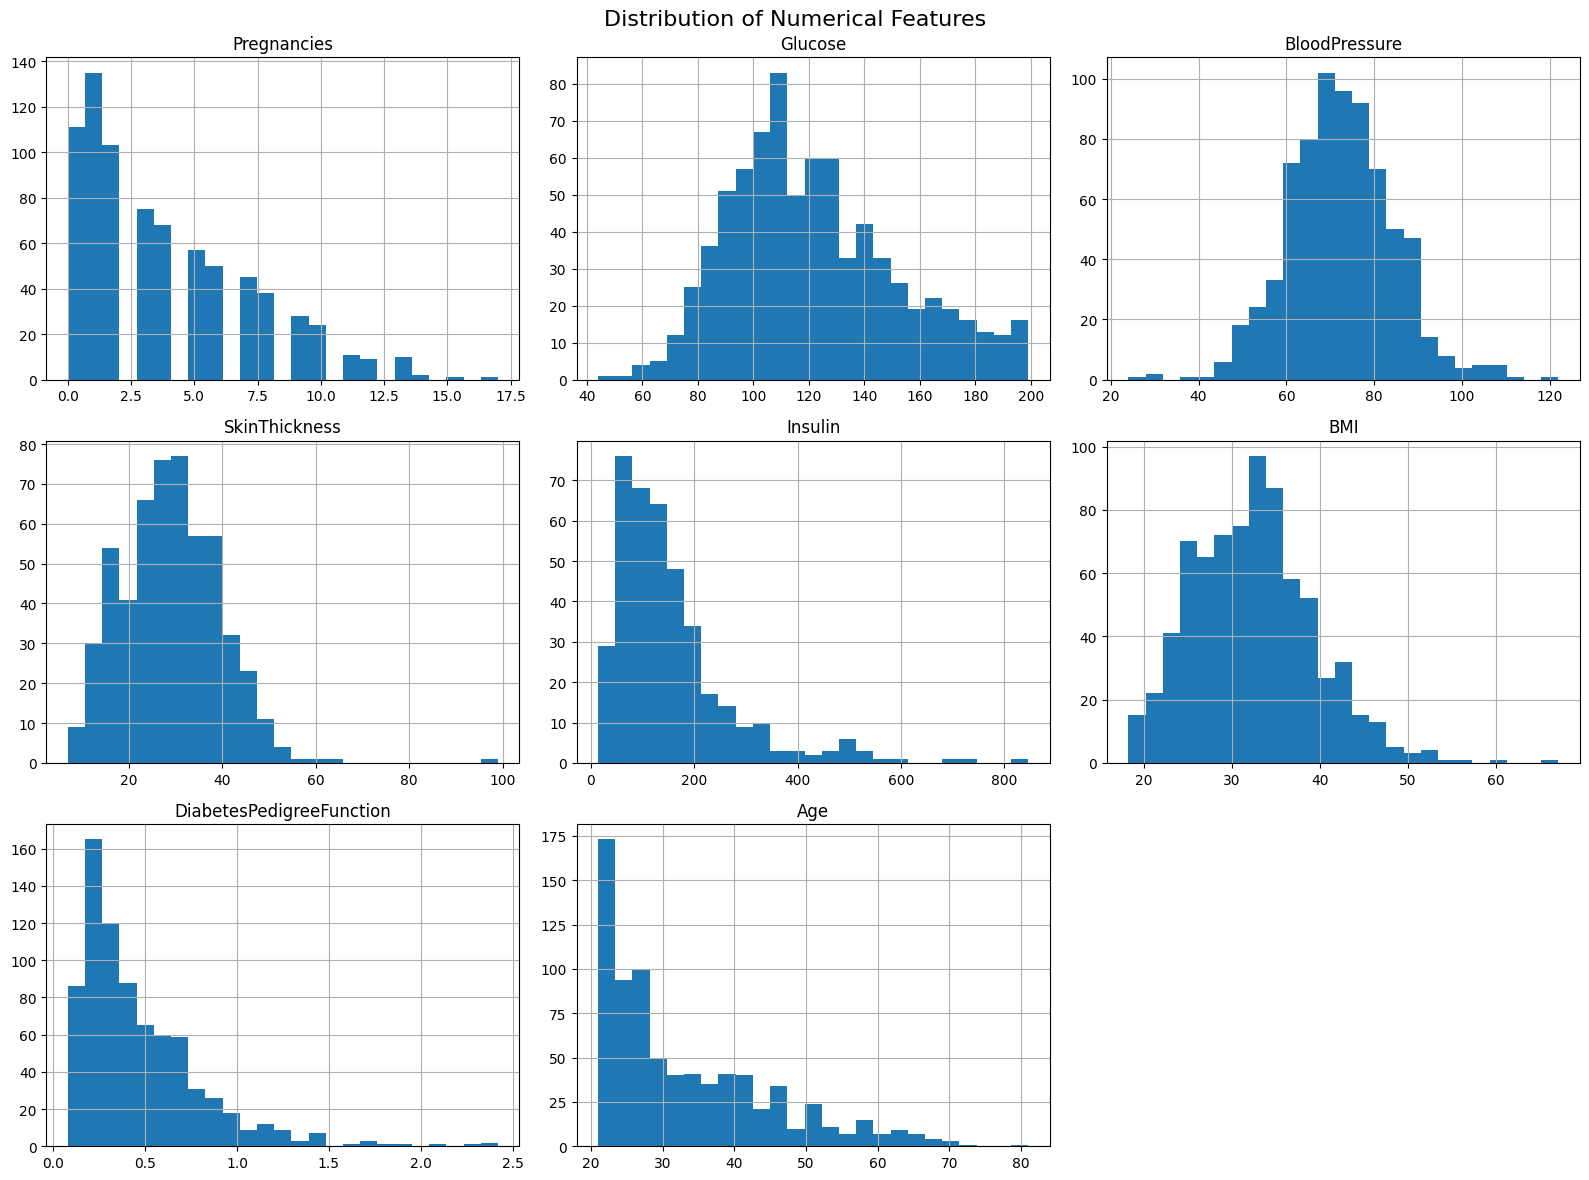

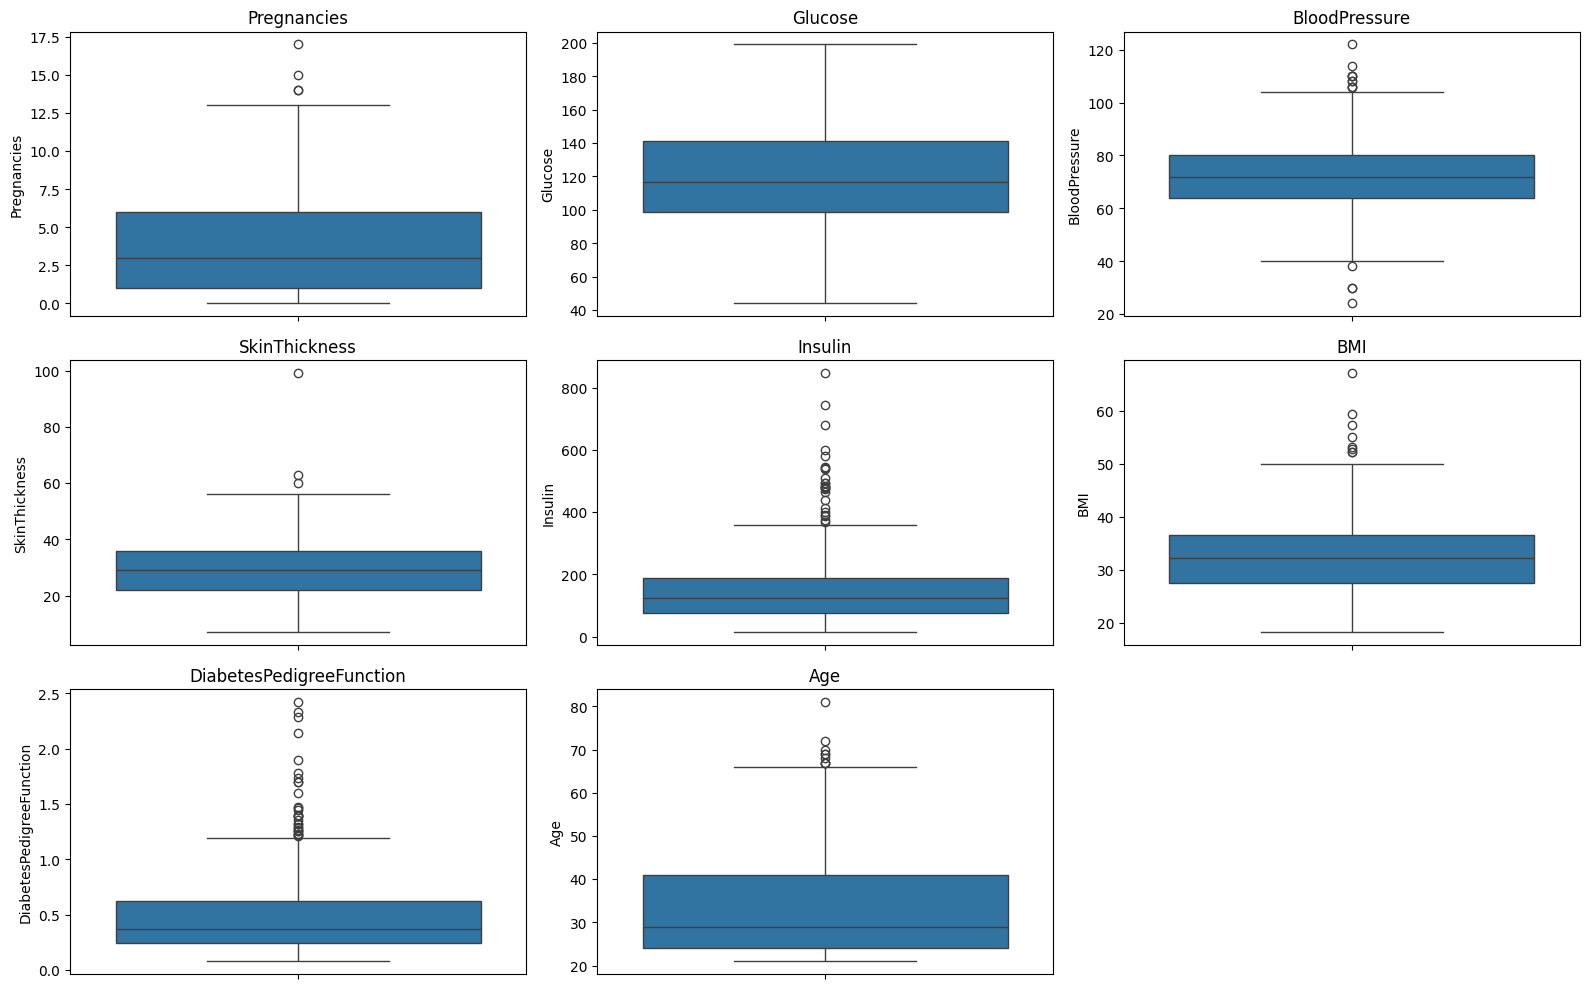

In [ ]:
numeric_features = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"
]

display(pd.DataFrame({
    "Mean": df_clean[numeric_features].mean(),
    "Median": df_clean[numeric_features].median(),
    "Std Dev": df_clean[numeric_features].std(),
    "Minimum": df_clean[numeric_features].min(),
    "Maximum": df_clean[numeric_features].max(),
    "Skewness": df_clean[numeric_features].skew()
}))

df_clean[numeric_features].hist(figsize=(16, 12), bins=25)
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

plt.figure(figsize=(16, 10))
for i, col in enumerate(numeric_features, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df_clean[col])
    plt.title(col)
plt.tight_layout()
plt.show()

## 7. Outlier Analysis using IQR

In [ ]:
outlier_summary = []

for col in numeric_features:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    count = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()

    outlier_summary.append({
        "Feature": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Outlier Count": count
    })

display(pd.DataFrame(outlier_summary))

print(
    "Decision: detected outliers are retained rather than blindly deleted. "
    "Clinical extremes can be genuine observations; scaling and regularization "
    "are used instead."
)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,Pregnancies,1.00000,6.00000,5.0000,-6.500,13.500,4
1,Glucose,99.00000,141.00000,42.0000,36.000,204.000,0
2,BloodPressure,64.00000,80.00000,16.0000,40.000,104.000,14
3,SkinThickness,22.00000,36.00000,14.0000,1.000,57.000,3
4,Insulin,76.25000,190.00000,113.7500,-94.375,360.625,24
5,BMI,27.50000,36.60000,9.1000,13.850,50.250,8
6,DiabetesPedigreeFunction,0.24375,0.62625,0.3825,-0.330,1.200,29
7,Age,24.00000,41.00000,17.0000,-1.500,66.500,9


Decision: detected outliers are retained rather than blindly deleted. Clinical extremes can be genuine observations; scaling and regularization are used instead.


## 8. Bivariate Analysis

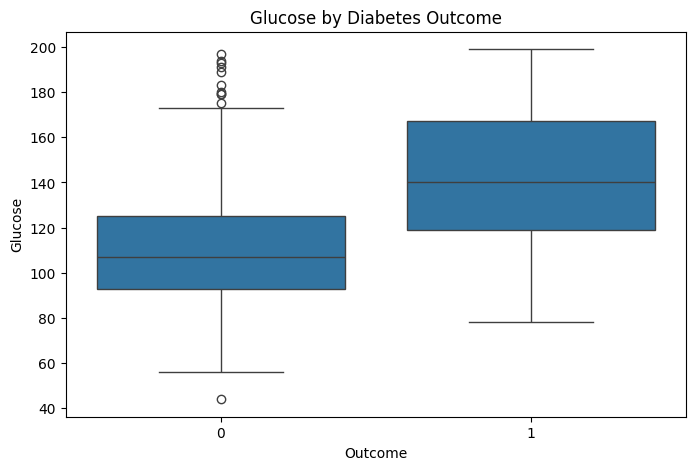

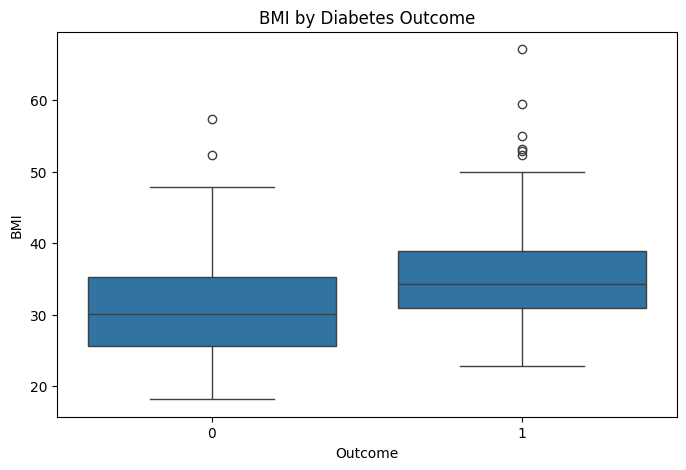

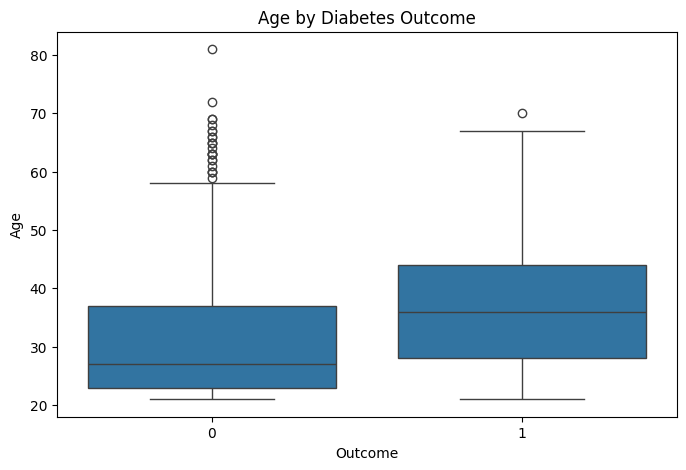

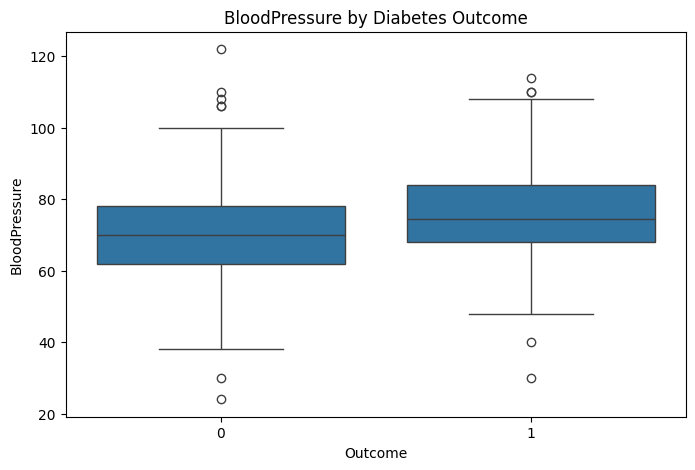

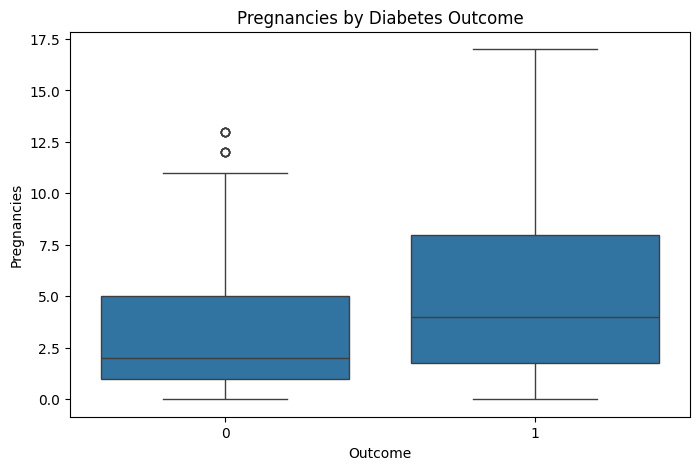

In [ ]:
for feature in ["Glucose", "BMI", "Age", "BloodPressure", "Pregnancies"]:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df_clean, x="Outcome", y=feature)
    plt.title(f"{feature} by Diabetes Outcome")
    plt.show()

## 9. Correlation Analysis

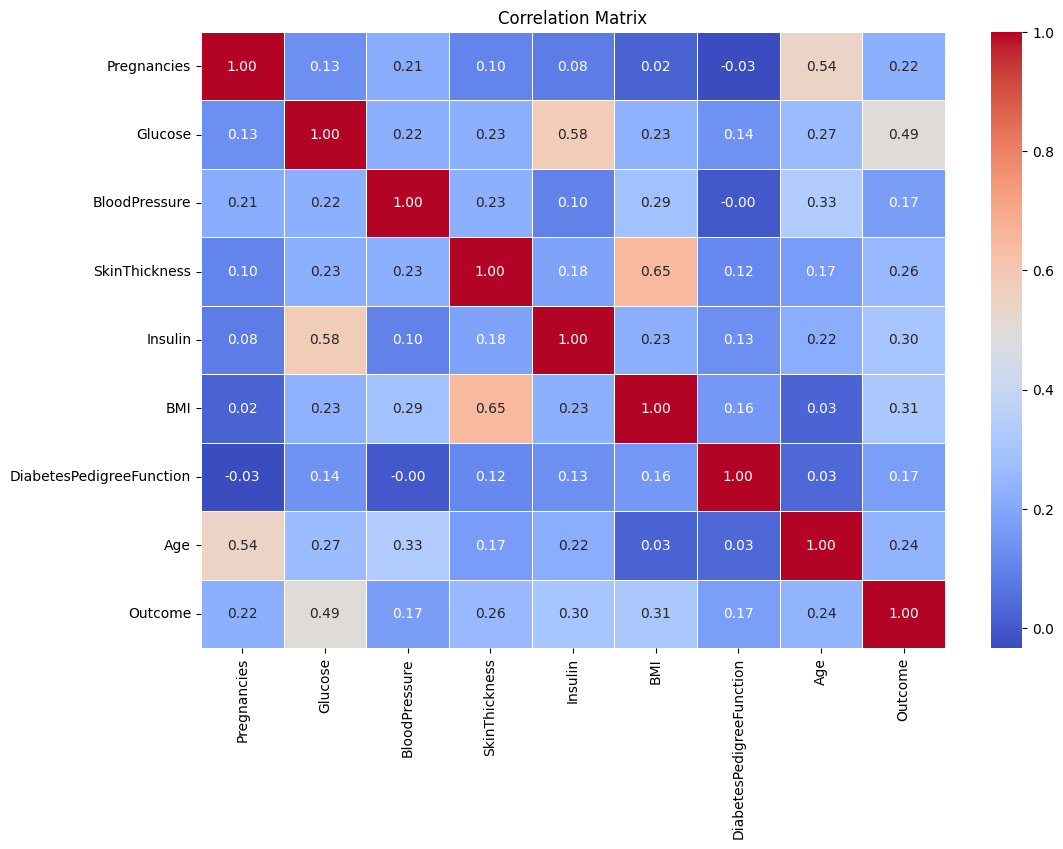

In [ ]:
corr = df_clean.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

## 10. Feature Engineering

In [ ]:
df_fe = df_clean.copy()

df_fe["BMI_Category"] = pd.cut(
    df_fe["BMI"],
    bins=[0, 18.5, 25, 30, np.inf],
    labels=["Underweight", "Normal", "Overweight", "Obese"]
)

df_fe["Age_Group"] = pd.cut(
    df_fe["Age"],
    bins=[0, 25, 40, 60, np.inf],
    labels=["Young", "Adult", "Middle_Aged", "Senior"]
)

df_fe["Glucose_Category"] = pd.cut(
    df_fe["Glucose"],
    bins=[0, 100, 125, np.inf],
    labels=["Normal", "Elevated", "High"]
)

df_fe["Glucose_BMI_Interaction"] = df_fe["Glucose"] * df_fe["BMI"]

display(df_fe.head())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Category,Age_Group,Glucose_Category,Glucose_BMI_Interaction
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1,Obese,Middle_Aged,High,4972.8
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0,Overweight,Adult,Normal,2261.0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1,Normal,Adult,High,4263.9
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,Overweight,Young,Normal,2500.9
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,Obese,Adult,High,5904.7


## 11. Train-Test Split

In [ ]:
X = df_fe.drop(columns="Outcome")
y = df_fe["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("\nTraining distribution:")
print(y_train.value_counts(normalize=True))
print("\nTesting distribution:")
print(y_test.value_counts(normalize=True))

Training samples: 614
Testing samples: 154

Training distribution:
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64

Testing distribution:
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


## 12. Preprocessing Pipeline — Fit Only on Training Data

In [ ]:
categorical_features = ["BMI_Category", "Age_Group", "Glucose_Category"]

numeric_features_model = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age",
    "Glucose_BMI_Interaction"
]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features_model),
    ("categorical", categorical_pipeline, categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (614, 20)
Processed testing shape: (154, 20)


## 13. Evaluation Helper

In [ ]:
def evaluate_model(name, model, Xtr, Xte, ytr, yte):
    start = time.time()
    model.fit(Xtr, ytr)
    elapsed = time.time() - start

    pred = model.predict(Xte)

    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(Xte)[:, 1]
    else:
        prob = model.decision_function(Xte)

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(yte, pred),
        "Precision": precision_score(yte, pred, zero_division=0),
        "Recall": recall_score(yte, pred, zero_division=0),
        "F1": f1_score(yte, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(yte, prob),
        "Training Time (sec)": elapsed
    }

    print("=" * 60)
    print(name)
    print("=" * 60)
    print(classification_report(
        yte, pred,
        target_names=["Non-Diabetic", "Diabetic"],
        zero_division=0
    ))

    return model, pred, prob, metrics

## 14. Baseline Model 1 — Logistic Regression

In [ ]:
lr_model = LogisticRegression(max_iter=2000, random_state=SEED)

lr_model, lr_pred, lr_prob, lr_metrics = evaluate_model(
    "Logistic Regression",
    lr_model,
    X_train_processed, X_test_processed,
    y_train, y_test
)

Logistic Regression
              precision    recall  f1-score   support

Non-Diabetic       0.78      0.82      0.80       100
    Diabetic       0.63      0.57      0.60        54

    accuracy                           0.73       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.73      0.73       154



## 15. Baseline Model 2 — KNN

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=7)

knn_model, knn_pred, knn_prob, knn_metrics = evaluate_model(
    "KNN",
    knn_model,
    X_train_processed, X_test_processed,
    y_train, y_test
)

KNN
              precision    recall  f1-score   support

Non-Diabetic       0.78      0.84      0.81       100
    Diabetic       0.65      0.56      0.60        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.74      0.73       154



## 16. Baseline Model 3 — SVM

In [ ]:
svm_model = SVC(
    kernel="rbf",
    probability=True,
    random_state=SEED
)

svm_model, svm_pred, svm_prob, svm_metrics = evaluate_model(
    "SVM",
    svm_model,
    X_train_processed, X_test_processed,
    y_train, y_test
)

SVM
              precision    recall  f1-score   support

Non-Diabetic       0.78      0.87      0.82       100
    Diabetic       0.69      0.54      0.60        54

    accuracy                           0.75       154
   macro avg       0.73      0.70      0.71       154
weighted avg       0.75      0.75      0.74       154



## 17. Baseline Model 4 — Random Forest

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    min_samples_split=5,
    class_weight="balanced",
    random_state=SEED
)

rf_model, rf_pred, rf_prob, rf_metrics = evaluate_model(
    "Random Forest",
    rf_model,
    X_train_processed, X_test_processed,
    y_train, y_test
)

Random Forest
              precision    recall  f1-score   support

Non-Diabetic       0.79      0.80      0.80       100
    Diabetic       0.62      0.61      0.62        54

    accuracy                           0.73       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.73      0.73      0.73       154



## 18. Baseline Model Comparison

In [ ]:
baseline_results = pd.DataFrame([
    lr_metrics, knn_metrics, svm_metrics, rf_metrics
])

display(baseline_results.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1": "{:.4f}",
    "ROC-AUC": "{:.4f}",
    "Training Time (sec)": "{:.4f}"
}))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Training Time (sec)
0,Logistic Regression,0.7338,0.6327,0.5741,0.6019,0.8304,0.0239
1,KNN,0.7403,0.6522,0.5556,0.6000,0.8103,0.0020
2,SVM,0.7532,0.6905,0.5370,0.6042,0.7949,0.0680
3,Random Forest,0.7338,0.6226,0.6111,0.6168,0.8328,1.0247


## 19. MLP Architecture

In [ ]:
def build_mlp(
    input_dim,
    hidden_units=(64, 32),
    learning_rate=0.001,
    dropout_rate=0.2,
    l2_strength=0.001
):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,))
    ])

    for units in hidden_units:
        model.add(layers.Dense(
            units,
            activation="relu",
            kernel_regularizer=regularizers.l2(l2_strength)
        ))
        model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.AUC(name="auc")
        ]
    )

    return model

input_dim = X_train_processed.shape[1]

mlp_model = build_mlp(
    input_dim,
    hidden_units=(64, 32),
    learning_rate=0.001,
    dropout_rate=0.2,
    l2_strength=0.001
)

mlp_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,457 (13.50 KB)

 Trainable params: 3,457 (13.50 KB)

 Non-trainable params: 0 (0.00 B)

## 20. Train Initial MLP

In [ ]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=7,
    min_lr=1e-6,
    verbose=1
)

start = time.time()

history = mlp_model.fit(
    X_train_processed,
    y_train,
    validation_split=0.20,
    epochs=200,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

mlp_training_time = time.time() - start
print(f"Training time: {mlp_training_time:.2f} seconds")

Epoch 1/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - accuracy: 0.6375 - auc: 0.6407 - loss: 0.7162 - precision: 0.4718 - recall: 0.3941 - val_accuracy: 0.7398 - val_auc: 0.8183 - val_loss: 0.6399 - val_precision: 0.7727 - val_recall: 0.3864 - learning_rate: 0.0010
Epoch 2/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.7169 - auc: 0.7811 - loss: 0.6258 - precision: 0.7013 - recall: 0.3176 - val_accuracy: 0.7724 - val_auc: 0.8434 - val_loss: 0.5765 - val_precision: 0.8077 - val_recall: 0.4773 - learning_rate: 0.0010
Epoch 3/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.7454 - auc: 0.8116 - loss: 0.5837 - precision: 0.7368 - recall: 0.4118 - val_accuracy: 0.7724 - val_auc: 0.8573 - val_loss: 0.5448 - val_precision: 0.7857 - val_recall: 0.5000 - learning_rate: 0.0010
Epoch 4/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7699 - auc: 0.8205 - loss: 0.5628 - precision: 0.7436 - recall: 0.5118 - val_accuracy: 0.7967 - val_auc: 0.8632 - val_loss: 0.5242 - va

## 21. MLP Learning Curves

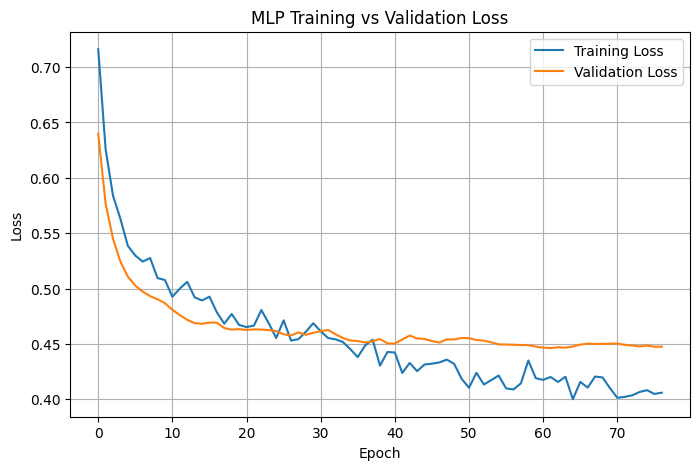

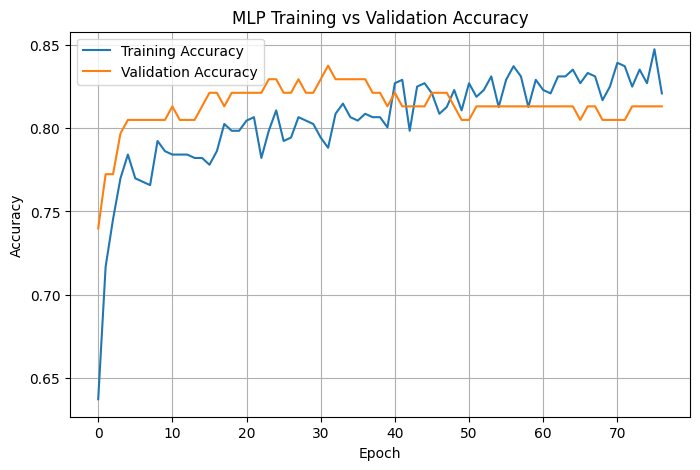

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLP Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MLP Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## 22. Initial MLP Evaluation

In [ ]:
mlp_prob = mlp_model.predict(X_test_processed, verbose=0).ravel()
mlp_pred = (mlp_prob >= 0.5).astype(int)

mlp_metrics = {
    "Model": "MLP",
    "Accuracy": accuracy_score(y_test, mlp_pred),
    "Precision": precision_score(y_test, mlp_pred, zero_division=0),
    "Recall": recall_score(y_test, mlp_pred, zero_division=0),
    "F1": f1_score(y_test, mlp_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, mlp_prob),
    "Training Time (sec)": mlp_training_time
}

print(classification_report(
    y_test, mlp_pred,
    target_names=["Non-Diabetic", "Diabetic"],
    zero_division=0
))

              precision    recall  f1-score   support

Non-Diabetic       0.80      0.81      0.81       100
    Diabetic       0.64      0.63      0.64        54

    accuracy                           0.75       154
   macro avg       0.72      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154



## 23. ROC and Precision-Recall Curves

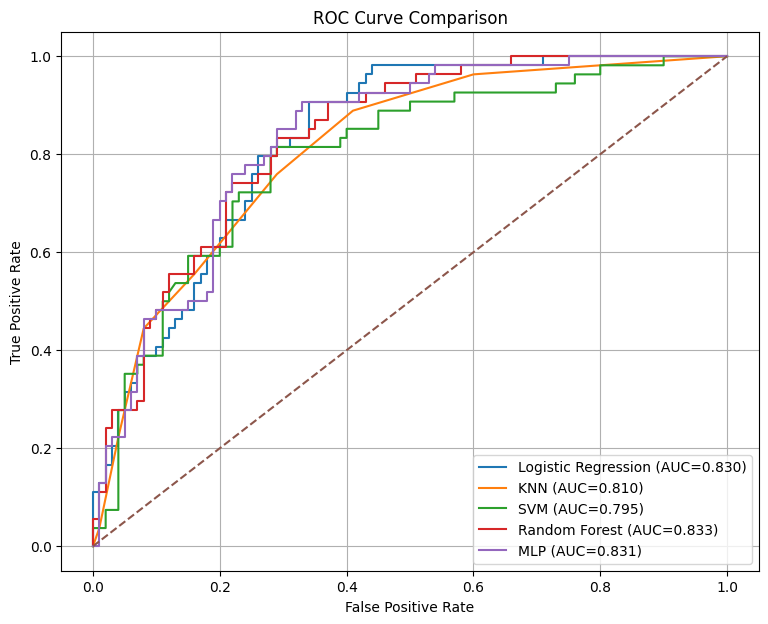

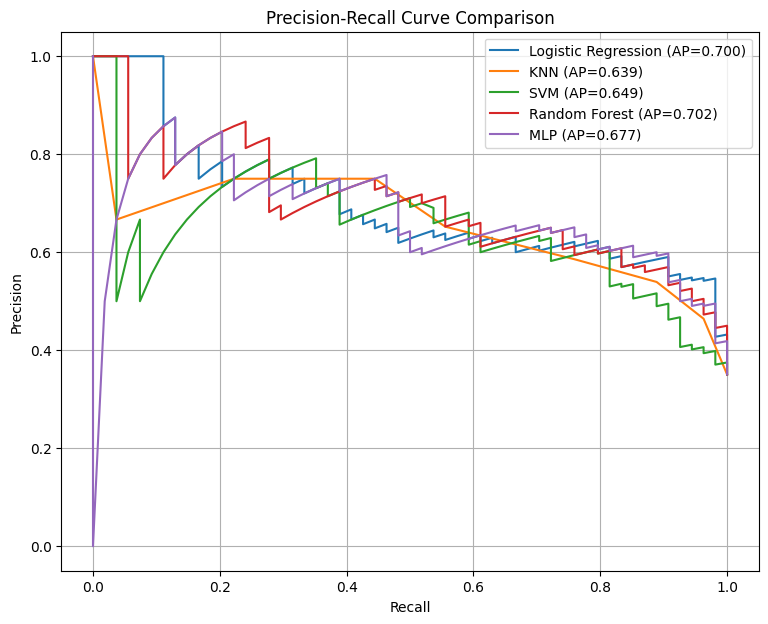

In [ ]:
probabilities = {
    "Logistic Regression": lr_prob,
    "KNN": knn_prob,
    "SVM": svm_prob,
    "Random Forest": rf_prob,
    "MLP": mlp_prob
}

plt.figure(figsize=(9, 7))

for name, prob in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 7))

for name, prob in probabilities.items():
    precision, recall, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    plt.plot(recall, precision, label=f"{name} (AP={ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()

## 24. Confusion Matrix Comparison

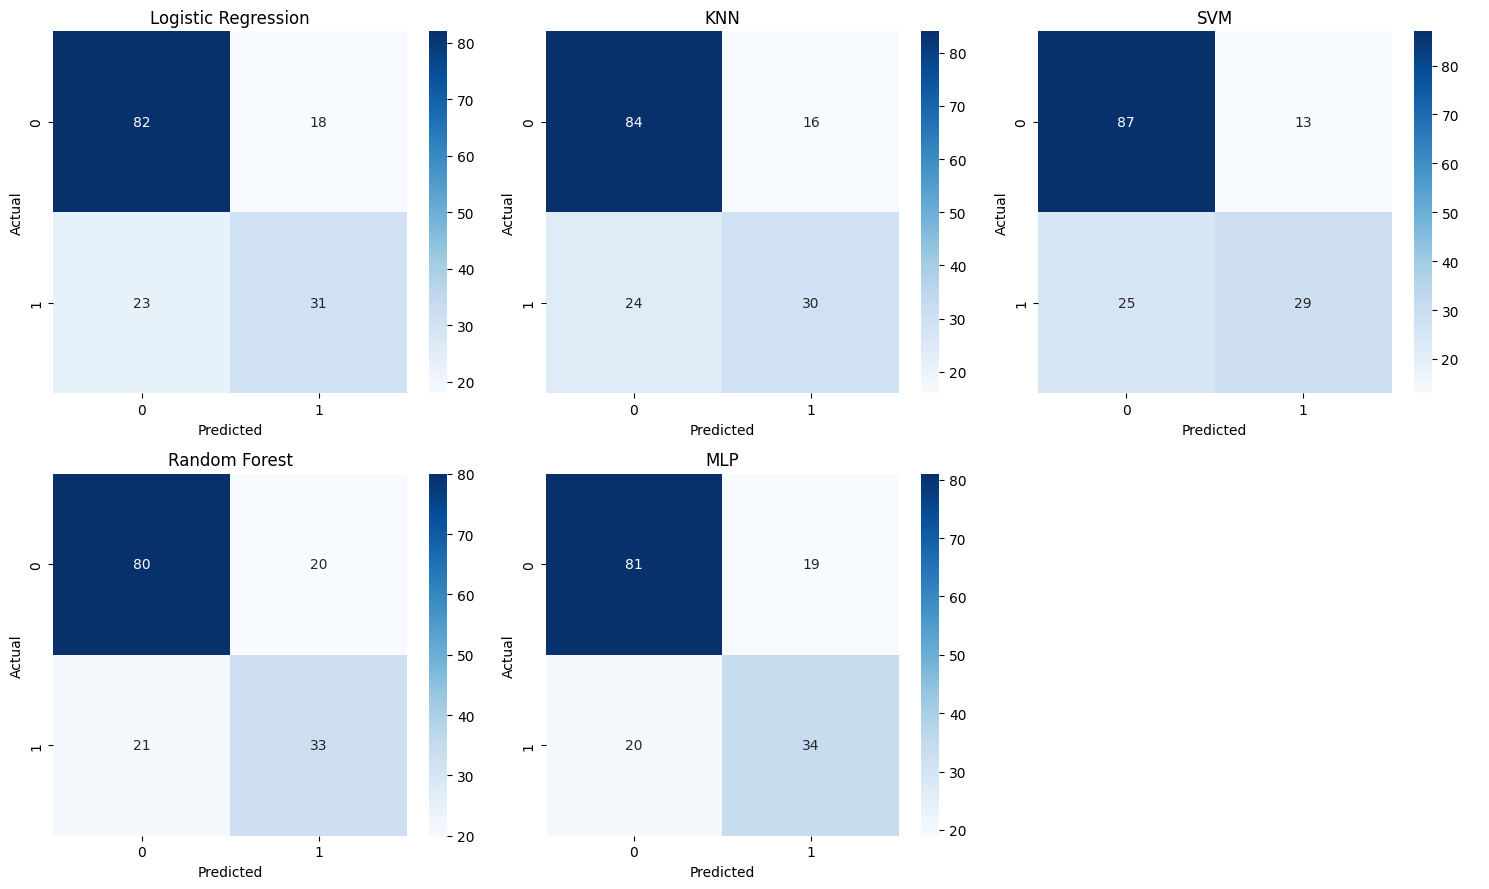

In [ ]:
predictions = {
    "Logistic Regression": lr_pred,
    "KNN": knn_pred,
    "SVM": svm_pred,
    "Random Forest": rf_pred,
    "MLP": mlp_pred
}

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

for ax, (name, pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

for ax in axes[len(predictions):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 25. MLP Hyperparameter Tuning — Validation Data Only

In [ ]:
# The test set is NOT used to select hyperparameters.
X_train_tune, X_val_tune, y_train_tune, y_val_tune = train_test_split(
    X_train_processed,
    y_train,
    test_size=0.20,
    random_state=SEED,
    stratify=y_train
)

configs = [
    {"hidden_units": (32,), "learning_rate": 0.001, "batch_size": 32, "dropout": 0.2},
    {"hidden_units": (64, 32), "learning_rate": 0.001, "batch_size": 32, "dropout": 0.2},
    {"hidden_units": (128, 64), "learning_rate": 0.001, "batch_size": 32, "dropout": 0.3},
    {"hidden_units": (64, 32, 16), "learning_rate": 0.0005, "batch_size": 32, "dropout": 0.3},
    {"hidden_units": (128, 64, 32), "learning_rate": 0.0005, "batch_size": 64, "dropout": 0.3},
    {"hidden_units": (64, 32), "learning_rate": 0.0005, "batch_size": 16, "dropout": 0.5}
]

tuning_results = []

for i, cfg in enumerate(configs, 1):
    print(f"Testing configuration {i}/{len(configs)}: {cfg}")

    model = build_mlp(
        input_dim=input_dim,
        hidden_units=cfg["hidden_units"],
        learning_rate=cfg["learning_rate"],
        dropout_rate=cfg["dropout"],
        l2_strength=0.001
    )

    stop = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=0
    )

    start = time.time()

    hist = model.fit(
        X_train_tune,
        y_train_tune,
        validation_data=(X_val_tune, y_val_tune),
        epochs=100,
        batch_size=cfg["batch_size"],
        callbacks=[stop],
        verbose=0
    )

    elapsed = time.time() - start

    val_prob = model.predict(X_val_tune, verbose=0).ravel()
    val_pred = (val_prob >= 0.5).astype(int)

    tuning_results.append({
        **cfg,
        "Validation Accuracy": accuracy_score(y_val_tune, val_pred),
        "Validation Precision": precision_score(y_val_tune, val_pred, zero_division=0),
        "Validation Recall": recall_score(y_val_tune, val_pred, zero_division=0),
        "Validation F1": f1_score(y_val_tune, val_pred, zero_division=0),
        "Validation ROC-AUC": roc_auc_score(y_val_tune, val_prob),
        "Epochs Used": len(hist.history["loss"]),
        "Training Time": elapsed
    })

tuning_df = pd.DataFrame(tuning_results).sort_values(
    "Validation ROC-AUC", ascending=False
).reset_index(drop=True)

display(tuning_df)

Testing configuration 1/6: {'hidden_units': (32,), 'learning_rate': 0.001, 'batch_size': 32, 'dropout': 0.2}
Testing configuration 2/6: {'hidden_units': (64, 32), 'learning_rate': 0.001, 'batch_size': 32, 'dropout': 0.2}


Testing configuration 3/6: {'hidden_units': (128, 64), 'learning_rate': 0.001, 'batch_size': 32, 'dropout': 0.3}
Testing configuration 4/6: {'hidden_units': (64, 32, 16), 'learning_rate': 0.0005, 'batch_size': 32, 'dropout': 0.3}
Testing configuration 5/6: {'hidden_units': (128, 64, 32), 'learning_rate': 0.0005, 'batch_size': 64, 'dropout': 0.3}
Testing configuration 6/6: {'hidden_units': (64, 32), 'learning_rate': 0.0005, 'batch_size': 16, 'dropout': 0.5}


,hidden_units,learning_rate,batch_size,dropout,Validation Accuracy,Validation Precision,Validation Recall,Validation F1,Validation ROC-AUC,Epochs Used,Training Time
0,"(64, 32)",0.0005,16,0.5,0.788618,0.707317,0.674419,0.690476,0.888953,46,11.744201
1,"(64, 32, 16)",0.0005,32,0.3,0.788618,0.707317,0.674419,0.690476,0.886047,59,12.539796
2,"(128, 64)",0.0010,32,0.3,0.780488,0.690476,0.674419,0.682353,0.885465,52,10.922811
3,"(128, 64, 32)",0.0005,64,0.3,0.788618,0.697674,0.697674,0.697674,0.878198,100,16.207527
4,"(64, 32)",0.0010,32,0.2,0.764228,0.675000,0.627907,0.650602,0.877907,34,6.652718
5,"(32,)",0.0010,32,0.2,0.764228,0.675000,0.627907,0.650602,0.872965,100,17.355386


## 26. Select the Best MLP Configuration

In [ ]:
display(tuning_df.style.format({
    "Validation Accuracy": "{:.4f}",
    "Validation Precision": "{:.4f}",
    "Validation Recall": "{:.4f}",
    "Validation F1": "{:.4f}",
    "Validation ROC-AUC": "{:.4f}",
    "Training Time": "{:.2f}"
}))

best_config = tuning_df.iloc[0].to_dict()

print("Selected configuration:")
print(best_config)

,hidden_units,learning_rate,batch_size,dropout,Validation Accuracy,Validation Precision,Validation Recall,Validation F1,Validation ROC-AUC,Epochs Used,Training Time
0,"(64, 32)",0.000500,16,0.500000,0.7886,0.7073,0.6744,0.6905,0.8890,46,11.74
1,"(64, 32, 16)",0.000500,32,0.300000,0.7886,0.7073,0.6744,0.6905,0.8860,59,12.54
2,"(128, 64)",0.001000,32,0.300000,0.7805,0.6905,0.6744,0.6824,0.8855,52,10.92
3,"(128, 64, 32)",0.000500,64,0.300000,0.7886,0.6977,0.6977,0.6977,0.8782,100,16.21
4,"(64, 32)",0.001000,32,0.200000,0.7642,0.6750,0.6279,0.6506,0.8779,34,6.65
5,"(32,)",0.001000,32,0.200000,0.7642,0.6750,0.6279,0.6506,0.8730,100,17.36


Selected configuration:
{'hidden_units': (64, 32), 'learning_rate': 0.0005, 'batch_size': 16, 'dropout': 0.5, 'Validation Accuracy': 0.7886178861788617, 'Validation Precision': 0.7073170731707317, 'Validation Recall': 0.6744186046511628, 'Validation F1': 0.6904761904761905, 'Validation ROC-AUC': 0.8889534883720931, 'Epochs Used': 46, 'Training Time': 11.744200706481934}


## 27. Final MLP Training

In [ ]:
final_mlp = build_mlp(
    input_dim=input_dim,
    hidden_units=best_config["hidden_units"],
    learning_rate=best_config["learning_rate"],
    dropout_rate=best_config["dropout"],
    l2_strength=0.001
)

final_history = final_mlp.fit(
    X_train_processed,
    y_train,
    validation_split=0.20,
    epochs=200,
    batch_size=int(best_config["batch_size"]),
    callbacks=[
        EarlyStopping(
            monitor="val_loss",
            patience=15,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=7,
            min_lr=1e-6,
            verbose=1
        )
    ],
    verbose=1
)

Epoch 1/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.5723 - auc: 0.5734 - loss: 0.7718 - precision: 0.4091 - recall: 0.5294 - val_accuracy: 0.6911 - val_auc: 0.7706 - val_loss: 0.6776 - val_precision: 0.5938 - val_recall: 0.4318 - learning_rate: 5.0000e-04
Epoch 2/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6802 - auc: 0.6833 - loss: 0.6908 - precision: 0.5399 - recall: 0.5176 - val_accuracy: 0.7398 - val_auc: 0.8119 - val_loss: 0.6314 - val_precision: 0.7143 - val_recall: 0.4545 - learning_rate: 5.0000e-04
Epoch 3/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6619 - auc: 0.6670 - loss: 0.6856 - precision: 0.5143 - recall: 0.4235 - val_accuracy: 0.7561 - val_auc: 0.8300 - val_loss: 0.5988 - val_precision: 0.7692 - val_recall: 0.4545 - learning_rate: 5.0000e-04
Epoch 4/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7047 - auc: 0.7242 - loss: 0.6424 - precision: 0.5874 - recall: 0.4941 - val_accuracy: 0.7805 - val_auc: 0.8412 - val_loss: 0.

## 28. Final Unseen-Test Evaluation

In [ ]:
final_prob = final_mlp.predict(X_test_processed, verbose=0).ravel()
final_pred = (final_prob >= 0.5).astype(int)

final_metrics = {
    "Model": "Final MLP",
    "Accuracy": accuracy_score(y_test, final_pred),
    "Precision": precision_score(y_test, final_pred, zero_division=0),
    "Recall": recall_score(y_test, final_pred, zero_division=0),
    "F1": f1_score(y_test, final_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, final_prob)
}

display(pd.DataFrame([final_metrics]).style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1": "{:.4f}",
    "ROC-AUC": "{:.4f}"
}))

print(classification_report(
    y_test, final_pred,
    target_names=["Non-Diabetic", "Diabetic"],
    zero_division=0
))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Final MLP,0.7208,0.6078,0.5741,0.5905,0.8231


              precision    recall  f1-score   support

Non-Diabetic       0.78      0.80      0.79       100
    Diabetic       0.61      0.57      0.59        54

    accuracy                           0.72       154
   macro avg       0.69      0.69      0.69       154
weighted avg       0.72      0.72      0.72       154



## 29. Final Confusion Matrix, ROC and PR Curves

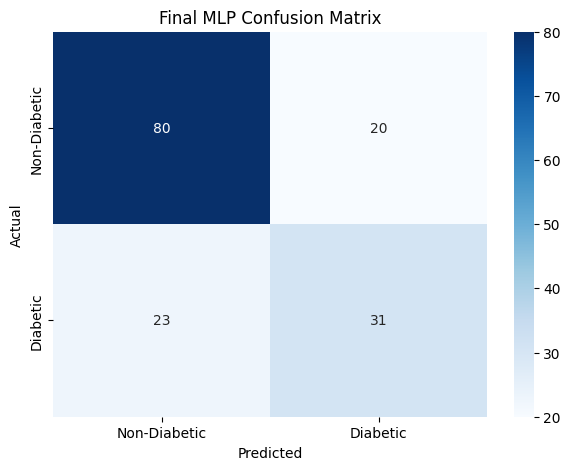

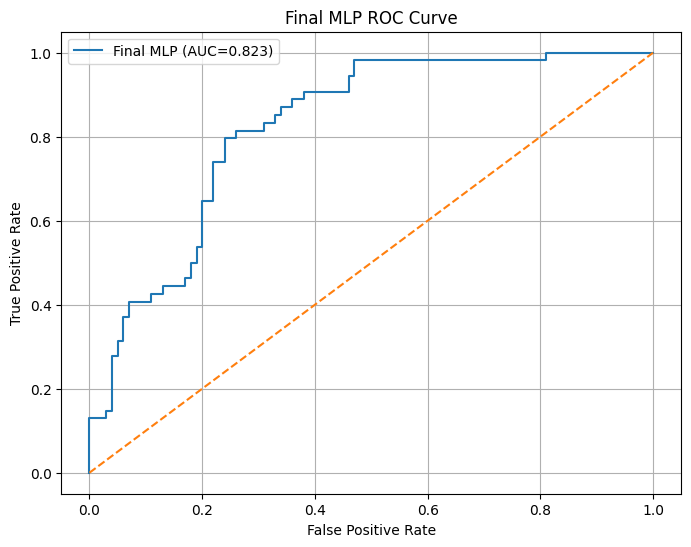

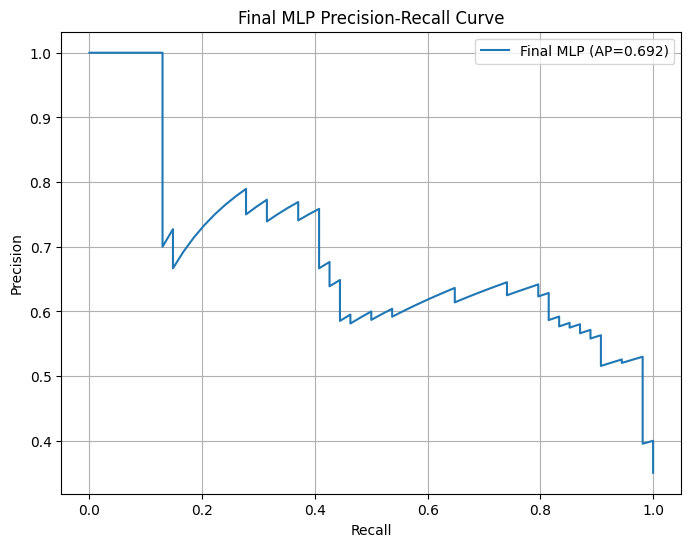

In [ ]:
cm = confusion_matrix(y_test, final_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Non-Diabetic", "Diabetic"],
    yticklabels=["Non-Diabetic", "Diabetic"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Final MLP Confusion Matrix")
plt.show()

fpr, tpr, _ = roc_curve(y_test, final_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Final MLP (AUC={final_metrics['ROC-AUC']:.3f})")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Final MLP ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

precision, recall, _ = precision_recall_curve(y_test, final_prob)
ap = average_precision_score(y_test, final_prob)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f"Final MLP (AP={ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Final MLP Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

## 30. Final Learning Curves

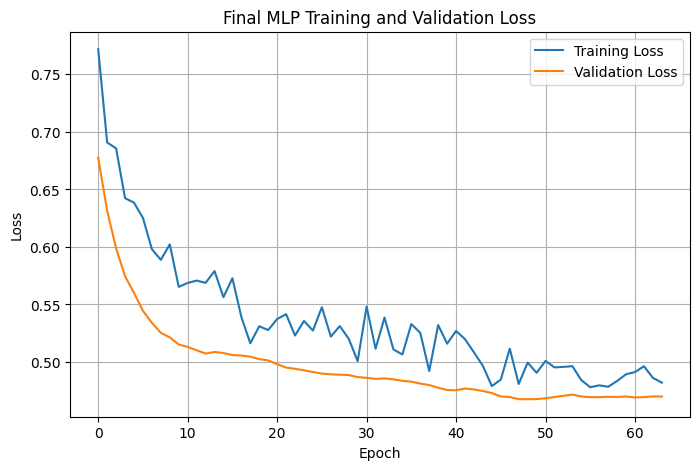

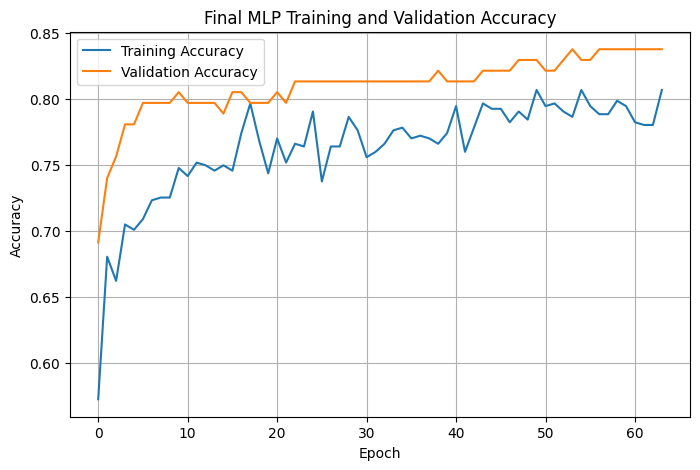

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(final_history.history["loss"], label="Training Loss")
plt.plot(final_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Final MLP Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(final_history.history["accuracy"], label="Training Accuracy")
plt.plot(final_history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Final MLP Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## 31. Final Model Comparison

In [ ]:
final_comparison = pd.DataFrame([
    lr_metrics,
    knn_metrics,
    svm_metrics,
    rf_metrics,
    {
        "Model": "Final MLP",
        "Accuracy": final_metrics["Accuracy"],
        "Precision": final_metrics["Precision"],
        "Recall": final_metrics["Recall"],
        "F1": final_metrics["F1"],
        "ROC-AUC": final_metrics["ROC-AUC"],
        "Training Time (sec)": np.nan
    }
])

display(final_comparison.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1": "{:.4f}",
    "ROC-AUC": "{:.4f}"
}))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Training Time (sec)
0,Logistic Regression,0.7338,0.6327,0.5741,0.6019,0.8304,0.023921
1,KNN,0.7403,0.6522,0.5556,0.6000,0.8103,0.001960
2,SVM,0.7532,0.6905,0.5370,0.6042,0.7949,0.068022
3,Random Forest,0.7338,0.6226,0.6111,0.6168,0.8328,1.024687
4,Final MLP,0.7208,0.6078,0.5741,0.5905,0.8231,nan


## 32. False-Negative Analysis

In [ ]:
tn, fp, fn, tp = confusion_matrix(y_test, final_pred).ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

if fn + tp:
    print(f"False Negative Rate: {fn / (fn + tp):.4f}")

print(
    "\nInterpretation: in a medical screening context, false negatives "
    "can be important because a diabetic patient may be predicted as "
    "non-diabetic. Therefore recall/sensitivity should be considered "
    "alongside accuracy, precision, F1 and ROC-AUC."
)

True Negatives : 80
False Positives: 20
False Negatives: 23
True Positives : 31
False Negative Rate: 0.4259

Interpretation: in a medical screening context, false negatives can be important because a diabetic patient may be predicted as non-diabetic. Therefore recall/sensitivity should be considered alongside accuracy, precision, F1 and ROC-AUC.


## 33. Save Model and Preprocessing Object

In [ ]:
final_mlp.save("diabetes_mlp.keras")
joblib.dump(preprocessor, "diabetes_preprocessor.pkl")

print("Saved:")
print(os.path.abspath("diabetes_mlp.keras"))
print(os.path.abspath("diabetes_preprocessor.pkl"))

Saved:
/content/diabetes_mlp.keras
/content/diabetes_preprocessor.pkl


## 34. Reload and Verify Saved Artifacts

In [ ]:
loaded_model = keras.models.load_model("diabetes_mlp.keras")
loaded_preprocessor = joblib.load("diabetes_preprocessor.pkl")

loaded_X_test = loaded_preprocessor.transform(X_test)
loaded_prob = loaded_model.predict(loaded_X_test, verbose=0).ravel()
loaded_pred = (loaded_prob >= 0.5).astype(int)

print("Loaded-model accuracy:",
      accuracy_score(y_test, loaded_pred))
print("Loaded-model ROC-AUC:",
      roc_auc_score(y_test, loaded_prob))

Loaded-model accuracy: 0.7207792207792207
Loaded-model ROC-AUC: 0.8231481481481482


## 35. Deployment Prediction Function

In [ ]:
def predict_diabetes(
    pregnancies,
    glucose,
    blood_pressure,
    skin_thickness,
    insulin,
    bmi,
    diabetes_pedigree,
    age
):
    data = pd.DataFrame({
        "Pregnancies": [pregnancies],
        "Glucose": [glucose],
        "BloodPressure": [blood_pressure],
        "SkinThickness": [skin_thickness],
        "Insulin": [insulin],
        "BMI": [bmi],
        "DiabetesPedigreeFunction": [diabetes_pedigree],
        "Age": [age]
    })

    for col in clinical_columns:
        data[col] = data[col].replace(0, np.nan)

    data["BMI_Category"] = pd.cut(
        data["BMI"],
        bins=[0, 18.5, 25, 30, np.inf],
        labels=["Underweight", "Normal", "Overweight", "Obese"]
    )

    data["Age_Group"] = pd.cut(
        data["Age"],
        bins=[0, 25, 40, 60, np.inf],
        labels=["Young", "Adult", "Middle_Aged", "Senior"]
    )

    data["Glucose_Category"] = pd.cut(
        data["Glucose"],
        bins=[0, 100, 125, np.inf],
        labels=["Normal", "Elevated", "High"]
    )

    data["Glucose_BMI_Interaction"] = data["Glucose"] * data["BMI"]

    processed = loaded_preprocessor.transform(data)
    probability = float(loaded_model.predict(processed, verbose=0)[0][0])

    prediction = "Diabetic" if probability >= 0.5 else "Non-Diabetic"

    return prediction, probability

## 36. Deployment Test Cases

In [ ]:
# Example 1
prediction, probability = predict_diabetes(
    pregnancies=1,
    glucose=100,
    blood_pressure=70,
    skin_thickness=20,
    insulin=80,
    bmi=24.0,
    diabetes_pedigree=0.3,
    age=25
)

print("Case 1")
print("Prediction:", prediction)
print(f"Probability: {probability * 100:.2f}%")

# Example 2
prediction, probability = predict_diabetes(
    pregnancies=6,
    glucose=180,
    blood_pressure=85,
    skin_thickness=30,
    insulin=150,
    bmi=35.0,
    diabetes_pedigree=0.8,
    age=50
)

print("\nCase 2")
print("Prediction:", prediction)
print(f"Probability: {probability * 100:.2f}%")

Case 1
Prediction: Non-Diabetic
Probability: 0.29%

Case 2
Prediction: Diabetic
Probability: 82.22%


## 37. Streamlit Deployment — Create `app.py`

In [ ]:
streamlit_code = r'''
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import tensorflow as tf

model = tf.keras.models.load_model("diabetes_mlp.keras")
preprocessor = joblib.load("diabetes_preprocessor.pkl")

st.set_page_config(page_title="Diabetes Prediction", page_icon="🩺")
st.title("🩺 Diabetes Prediction System")
st.write("Enter patient information to obtain a model prediction and probability.")

pregnancies = st.number_input("Pregnancies", 0, 20, 1)
glucose = st.number_input("Glucose", 1.0, 300.0, 100.0)
blood_pressure = st.number_input("Blood Pressure", 1.0, 200.0, 70.0)
skin_thickness = st.number_input("Skin Thickness", 0.0, 100.0, 20.0)
insulin = st.number_input("Insulin", 0.0, 900.0, 80.0)
bmi = st.number_input("BMI", 1.0, 80.0, 25.0)
pedigree = st.number_input("Diabetes Pedigree Function", 0.0, 3.0, 0.3)
age = st.number_input("Age", 1, 120, 25)

if st.button("Predict Diabetes"):

    data = pd.DataFrame({
        "Pregnancies": [pregnancies],
        "Glucose": [glucose],
        "BloodPressure": [blood_pressure],
        "SkinThickness": [skin_thickness],
        "Insulin": [insulin],
        "BMI": [bmi],
        "DiabetesPedigreeFunction": [pedigree],
        "Age": [age]
    })

    for col in ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]:
        data[col] = data[col].replace(0, np.nan)

    data["BMI_Category"] = pd.cut(
        data["BMI"], [0, 18.5, 25, 30, np.inf],
        labels=["Underweight", "Normal", "Overweight", "Obese"]
    )

    data["Age_Group"] = pd.cut(
        data["Age"], [0, 25, 40, 60, np.inf],
        labels=["Young", "Adult", "Middle_Aged", "Senior"]
    )

    data["Glucose_Category"] = pd.cut(
        data["Glucose"], [0, 100, 125, np.inf],
        labels=["Normal", "Elevated", "High"]
    )

    data["Glucose_BMI_Interaction"] = data["Glucose"] * data["BMI"]

    processed = preprocessor.transform(data)
    probability = float(model.predict(processed, verbose=0)[0][0])

    prediction = "Diabetic" if probability >= 0.5 else "Non-Diabetic"

    st.subheader("Prediction Result")
    st.write(f"### Prediction: {prediction}")
    st.write(f"### Diabetes Probability: {probability * 100:.2f}%")
'''

with open("app.py", "w", encoding="utf-8") as f:
    f.write(streamlit_code)

print("app.py created successfully.")
print("Run with: streamlit run app.py")

app.py created successfully.
Run with: streamlit run app.py


In [4]:
from pathlib import Path
import matplotlib.pyplot as plt

OUTPUT_DIR = Path("diabetes_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

figure_count = 0

_original_show = plt.show

def save_and_show(*args, **kwargs):
    global figure_count

    for fig_num in plt.get_fignums():
        fig = plt.figure(fig_num)

        figure_count += 1

        filename = OUTPUT_DIR / f"figure_{figure_count:02d}.png"

        fig.savefig(
            filename,
            dpi=300,
            bbox_inches="tight"
        )

    _original_show(*args, **kwargs)

plt.show = save_and_show

print("All graphs will be saved in:", OUTPUT_DIR)

All graphs will be saved in: diabetes_outputs


In [5]:
import shutil

zip_path = shutil.make_archive(
    "diabetes_graphs",
    "zip",
    "diabetes_outputs"
)

print("Created:", zip_path)

Created: /content/diabetes_graphs.zip


In [6]:
import os

for root, dirs, files in os.walk("/content"):
    if "diabetes_graphs" in root:
        print(root)
        for f in files:
            print("   ", f)

## 38. Conclusion

The notebook completes the required end-to-end machine-learning/deep-learning workflow:

- Dataset understanding and EDA
- Data-quality investigation
- Missing/suspicious-value handling
- Feature engineering
- Leakage-safe preprocessing
- Logistic Regression, KNN, SVM and Random Forest baselines
- MLP development
- Regularization and early stopping
- Accuracy, precision, recall, F1, ROC-AUC and confusion-matrix evaluation
- ROC and Precision-Recall curves
- MLP hyperparameter tuning using validation data
- Final unseen-test evaluation
- Model and preprocessor saving
- Deployment prediction function
- Streamlit application generation

**Do not manually invent final metric values in the report. Run the notebook and use the values produced by the actual experiment.**

The resulting model is an educational predictive system and should not be presented as a standalone medical diagnostic system.